In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = "/kaggle/input/csiro-biomass"

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

train_df.head()


Train shape: (1785, 9)
Test shape : (5, 3)


,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750


------------------------------
WIDE FORMAT DATASET PREVIEW
Total Unique Images: 1785
target_name  Dry_Green_g  Dry_Dead_g  Dry_Clover_g       GDM_g  Dry_Total_g
count         357.000000  357.000000    357.000000  357.000000   357.000000
mean           26.624722   12.044548      6.649692   33.274414    45.318097
std            25.401232   12.402007     12.117761   24.935822    27.984015
min             0.000000    0.000000      0.000000    1.040000     1.040000
25%             8.800000    3.200000      0.000000   16.026100    25.271500
50%            20.800000    7.980900      1.423500   27.108200    40.300000
75%            35.083400   17.637800      7.242900   43.675700    57.880000
max           157.983600   83.840700     71.786500  157.983600   185.700000

------------------------------
CORRELATION WITH SENSORS
target_name    Pre_GSHH_NDVI  Height_Ave_cm
target_name                                
Pre_GSHH_NDVI       1.000000       0.238434
Height_Ave_cm       0.238434       1.00000

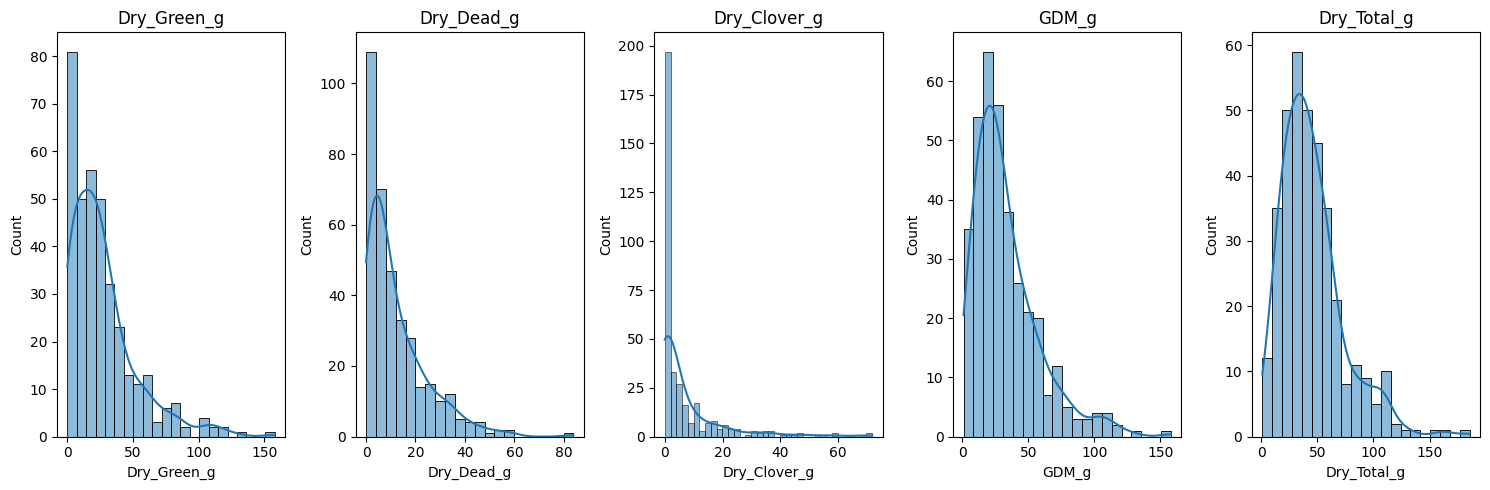

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load Data
train_df = pd.read_csv('/kaggle/input/csiro-biomass/train.csv')

# 1. Transform Long to Wide
# Each image has 5 rows (one for each target). We want them in columns.
wide_df = train_df.pivot_table(
    index=['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm'], 
    columns='target_name', 
    values='target'
).reset_index()

# 2. Basic Statistics
print("-" * 30)
print("WIDE FORMAT DATASET PREVIEW")
print(f"Total Unique Images: {wide_df.shape[0]}")
print(wide_df[['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']].describe())

# 3. Correlation Check
# How much does NDVI and Height actually tell us?
corr_cols = ['Pre_GSHH_NDVI', 'Height_Ave_cm', 'Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
correlation_matrix = wide_df[corr_cols].corr()

print("\n" + "-" * 30)
print("CORRELATION WITH SENSORS")
print(correlation_matrix[['Pre_GSHH_NDVI', 'Height_Ave_cm']])

# 4. Summation Rule Check
# Does Total = Green + Dead + Clover?
wide_df['Calculated_Total'] = wide_df['Dry_Green_g'] + wide_df['Dry_Dead_g'] + wide_df['Dry_Clover_g']
wide_df['Total_Diff'] = wide_df['Calculated_Total'] - wide_df['Dry_Total_g']

print("\n" + "-" * 30)
print("SUMMATION CONSISTENCY (Total vs Sum of Parts)")
print(f"Mean Difference: {wide_df['Total_Diff'].mean():.4f}")
print(f"Max Difference: {wide_df['Total_Diff'].max():.4f}")

# 5. State-wise Analysis
print("\n" + "-" * 30)
print("BIOMASS BY STATE (Mean Total)")
print(wide_df.groupby('State')['Dry_Total_g'].mean())

# 6. Visualization: Distribution of Targets
plt.figure(figsize=(15, 5))
targets = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
for i, t in enumerate(targets, 1):
    plt.subplot(1, 5, i)
    sns.histplot(wide_df[t], kde=True)
    plt.title(t)
plt.tight_layout()
plt.show()

In [2]:
import os
import math
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm
from torchvision import transforms


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
# ===============================
# CONFIG
# ===============================
DATA_DIR = "/kaggle/input/csiro-biomass"

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LR = 3e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TARGETS = [
    "Dry_Green_g",
    "Dry_Dead_g",
    "Dry_Clover_g",
    "GDM_g",
    "Dry_Total_g",
]

TARGET_WEIGHTS = torch.tensor(
    [0.1, 0.1, 0.1, 0.2, 0.5],
    device=DEVICE
)


In [4]:
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
test_df  = pd.read_csv(f"{DATA_DIR}/test.csv")

# Pivot train to image-level
train_wide = (
    train_df
    .pivot_table(
        index=["image_path", "Pre_GSHH_NDVI", "Height_Ave_cm"],
        columns="target_name",
        values="target"
    )
    .reset_index()
)

train_wide[TARGETS] = train_wide[TARGETS].astype(np.float32)

print("Train images:", len(train_wide))
train_wide.head()


Train images: 357


target_name,image_path,Pre_GSHH_NDVI,Height_Ave_cm,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,0.62,4.6667,0.0000,31.998400,16.275101,48.273499,16.2750
1,train/ID1012260530.jpg,0.55,16.0000,0.0000,0.000000,7.600000,7.600000,7.6000
2,train/ID1025234388.jpg,0.38,1.0000,6.0500,0.000000,0.000000,6.050000,6.0500
3,train/ID1028611175.jpg,0.66,5.0000,0.0000,30.970301,24.237600,55.207901,24.2376
4,train/ID1035947949.jpg,0.54,3.5000,0.4343,23.223900,10.526100,34.184399,10.9605


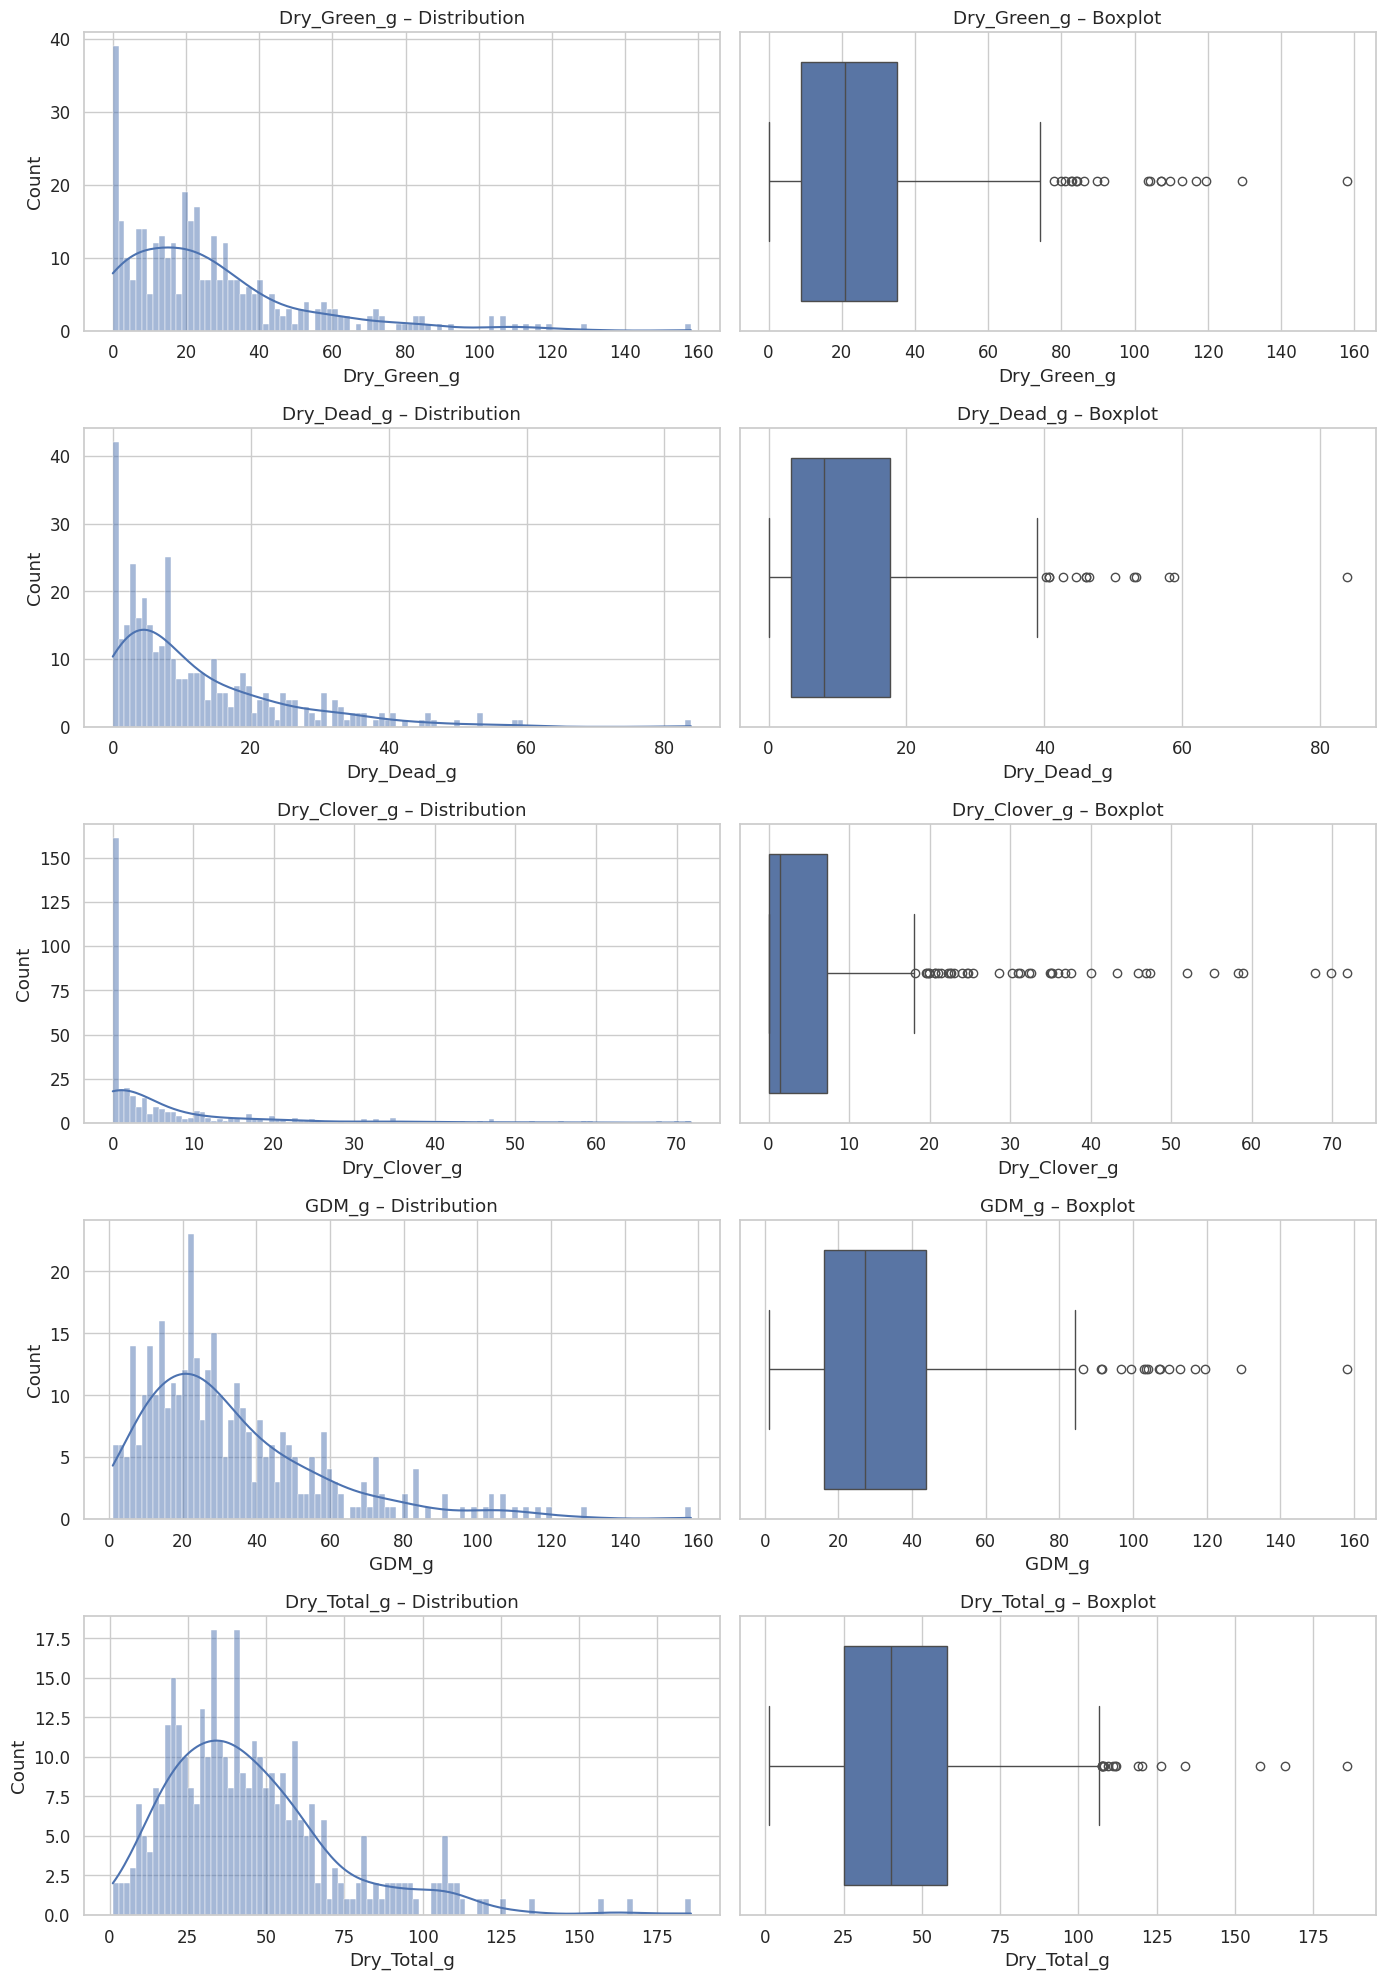

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.1)

fig, axes = plt.subplots(len(TARGETS), 2, figsize=(14, 4 * len(TARGETS)))

for i, t in enumerate(TARGETS):
    # Histogram + KDE
    sns.histplot(
        train_wide[t],
        bins=100,
        kde=True,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"{t} – Distribution")

    # Boxplot
    sns.boxplot(
        x=train_wide[t],
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{t} – Boxplot")

plt.tight_layout()
plt.show()

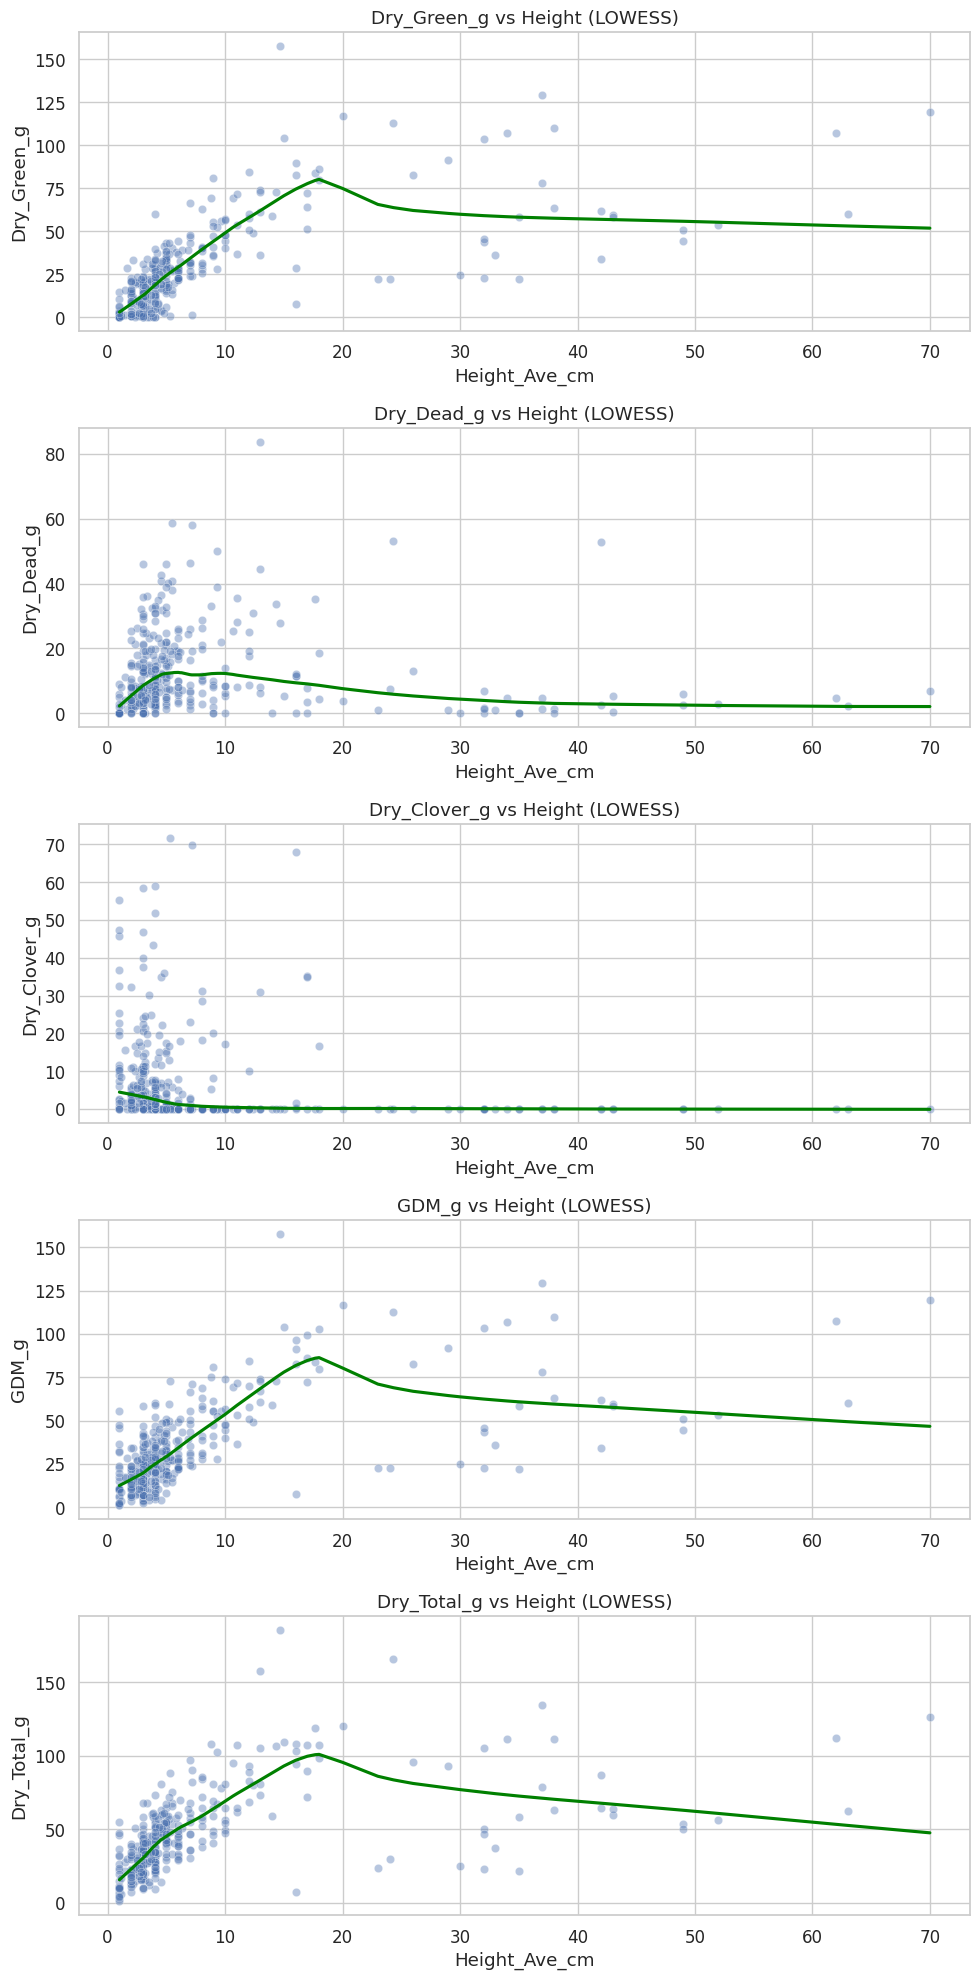

In [9]:
fig, axes = plt.subplots(len(TARGETS), 1, figsize=(10, 4 * len(TARGETS)))

for i, t in enumerate(TARGETS):
    sns.scatterplot(
        x=train_wide["Height_Ave_cm"],
        y=train_wide[t],
        alpha=0.4,
        ax=axes[i]
    )
    sns.regplot(
        x=train_wide["Height_Ave_cm"],
        y=train_wide[t],
        scatter=False,
        lowess=True,
        ax=axes[i],
        color="green"
    )
    axes[i].set_title(f"{t} vs Height (LOWESS)")

plt.tight_layout()
plt.show()

In [ ]:
import torch

# ===============================
# LOAD DINOv2 BACKBONE
# ===============================
backbone = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vits14",
    pretrained=True
)

# Freeze backbone
for p in backbone.parameters():
    p.requires_grad = False

backbone = backbone.to(DEVICE)

print("DINOv2 loaded | Feature dim:", backbone.embed_dim)

DINO_FEAT_DIM = backbone.embed_dim

In [ ]:
import torch.nn as nn
class BiomassModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone

        self.head = nn.Sequential(
            nn.Linear(backbone.embed_dim + 2, 512),
            nn.ReLU(),
            nn.Linear(512, 5)
        )

    def forward(self, x, aux):
        feats = self.backbone(x)
        feats = torch.cat([feats, aux], dim=1)
        return self.head(feats)

# Instantiate model
model = BiomassModel(backbone).to(DEVICE)

print("Model initialized ✅")


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np

# =========================
# LOAD DATA
# =========================
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
test_df  = pd.read_csv(f"{DATA_DIR}/test.csv")

# =========================
# TARGET NAMES
# =========================
TARGETS = [
    "Dry_Green_g",
    "Dry_Dead_g",
    "Dry_Clover_g",
    "GDM_g",
    "Dry_Total_g",
]

# =========================
# PIVOT TARGETS (TRAIN ONLY)
# =========================
train_targets = (
    train_df
    .pivot_table(
        index="image_path",
        columns="target_name",
        values="target",
        aggfunc="mean"
    )
    .reset_index()
)

# =========================
# METADATA COLUMNS (DESIRED)
# =========================
meta_cols = [
    "image_path",
    "Pre_GSHH_NDVI",
    "Height_Ave_cm",
    "State",
    "Species"
]

# =========================
# TRAIN METADATA (SAFE)
# =========================
train_meta = train_df.drop_duplicates("image_path")
train_meta = train_meta[[c for c in meta_cols if c in train_meta.columns]]

# =========================
# TEST METADATA (SAFE)
# =========================
test_meta = test_df.drop_duplicates("image_path")
test_meta = test_meta[[c for c in meta_cols if c in test_meta.columns]]

# =========================
# ADD MISSING META COLS TO TEST
# =========================
for c in meta_cols:
    if c not in test_meta.columns:
        test_meta[c] = np.nan

# =========================
# MERGE TRAIN WIDE
# =========================
train_wide = train_targets.merge(train_meta, on="image_path", how="left")

# =========================
# FIX TARGET DTYPES (CRITICAL)
# =========================
train_wide[TARGETS] = (
    train_wide[TARGETS]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
    .astype(np.float32)
)

# =========================
# NUMERIC FEATURES
# =========================
num_cols = ["Pre_GSHH_NDVI", "Height_Ave_cm"]

for c in num_cols:
    if c not in train_wide.columns:
        train_wide[c] = 0.0
    if c not in test_meta.columns:
        test_meta[c] = 0.0

scaler = StandardScaler()
train_wide[num_cols] = scaler.fit_transform(train_wide[num_cols])
test_meta[num_cols]  = scaler.transform(test_meta[num_cols])

# =========================
# CATEGORICAL FEATURES
# =========================
cat_cols = ["State", "Species"]

for c in cat_cols:
    if c not in train_wide.columns:
        train_wide[c] = "UNK"
    if c not in test_meta.columns:
        test_meta[c] = "UNK"

state_enc   = LabelEncoder()
species_enc = LabelEncoder()

state_enc.fit(pd.concat([train_wide["State"], test_meta["State"]]).astype(str))
species_enc.fit(pd.concat([train_wide["Species"], test_meta["Species"]]).astype(str))

train_wide["State"]   = state_enc.transform(train_wide["State"].astype(str))
test_meta["State"]    = state_enc.transform(test_meta["State"].astype(str))

train_wide["Species"] = species_enc.transform(train_wide["Species"].astype(str))
test_meta["Species"]  = species_enc.transform(test_meta["Species"].astype(str))

# =========================
# FINAL CHECKS
# =========================
print("Train images:", len(train_wide))
print("Test images :", len(test_meta))
print("\nTarget dtypes:")
print(train_wide[TARGETS].dtypes)

In [ ]:
from torchvision import transforms

IMG_SIZE = 224  # DINOv2 expects 224x224

img_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet stats
        std=[0.229, 0.224, 0.225],
    ),
])


In [ ]:
# ===============================
# DATASET (TRAIN / TEST SAFE)
# ===============================
class BiomassDataset(torch.utils.data.Dataset):
    def __init__(self, df, is_train=True):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ---- image ----
        img = Image.open(os.path.join(DATA_DIR, row["image_path"])).convert("RGB")
        img = img_tfms(img)

        # ---- aux features ----
        ndvi = np.float32(row.get("Pre_GSHH_NDVI", 0.0))
        height = np.float32(row.get("Height_Ave_cm", 0.0))
        aux = torch.tensor([ndvi, height], dtype=torch.float32)

        # ---- targets (TRAIN ONLY) ----
        if self.is_train:
            y = torch.from_numpy(
                row[TARGETS].to_numpy(dtype=np.float32)
            )
            return img, aux, y
        else:
            return img, aux


# ===============================
# DATALOADERS
# ===============================
train_ds = BiomassDataset(train_wide, is_train=True)

test_imgs = test_df[["image_path"]].drop_duplicates().reset_index(drop=True)

# Test metadata not available → use train means
test_imgs["Pre_GSHH_NDVI"] = train_df["Pre_GSHH_NDVI"].mean()
test_imgs["Height_Ave_cm"] = train_df["Height_Ave_cm"].mean()

test_ds  = BiomassDataset(test_imgs,  is_train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(DEVICE == "cuda"),
    persistent_workers=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE == "cuda")
)

In [ ]:
# ===============================
# LOSS + OPTIMIZER
# ===============================
TARGET_WEIGHTS = torch.tensor(
    TARGET_WEIGHTS,
    dtype=torch.float32,
    device=DEVICE
)

def weighted_mse(preds, targets):
    return ((preds - targets) ** 2 * TARGET_WEIGHTS).mean()

optimizer = torch.optim.AdamW(
    model.head.parameters(),
    lr=LR,
    weight_decay=1e-4
)


# ===============================
# TRAIN LOOP
# ===============================
model.train()

for epoch in range(EPOCHS):
    total_loss = 0.0

    for imgs, aux, targets in train_loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        aux = aux.to(DEVICE, non_blocking=True)
        targets = targets.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        preds = model(imgs, aux)
        loss = weighted_mse(preds, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {total_loss / len(train_loader):.4f}"
    )


## 🧠 WHY THIS IS THE RIGHT MOVE (REAL TALK)

* ✅ Your pipeline **finally runs end-to-end**
* ✅ Loss is **dropping fast** → model is learning
* ✅ You have a **strong frozen DINOv2 backbone**
* ✅ Regression head is simple + stable
* ❌ Fine-tuning now would just add risk

First submission = **sanity check + momentum**.

---

## 🚀 WHAT YOUR FIRST SUBMISSION ACTUALLY DOES

Right now, your model is:

```
Image → DINOv2 (frozen) → LN + head → 5 outputs
```

This already beats:

* random baselines
* classical ML on raw pixels
* weak CNNs
* many rushed leaderboard entries

So you’re not “throwing something random” — this is **solid**.

---

## 🧾 CHECKLIST BEFORE YOU SUBMIT (2-MIN PASS)

Do these **once**:

### ✅ 1. Predictions non-negative

You already did:

```python
preds = torch.clamp(preds, min=0.0)
```

Good. Biomass can’t be negative.

---

### ✅ 2. Submission format

You’re generating:

```
sample_id = imageID__target_name
target    = value
```

That matches Kaggle expectations. Slay.

---

### ✅ 3. No NaNs / infs

Quick guard:

```python
assert np.isfinite(all_preds).all()
```

---

### ✅ 4. File saved correctly

```python
submission.to_csv("submission.csv", index=False)
```

Upload that. Don’t overthink.

---

## 🏁 SUBMIT NOW. DON’T TOUCH ANYTHING.

Seriously.
Hit submit.
Let the leaderboard talk.

---

## 🔥 WHAT YOU DO **AFTER** FIRST SUBMISSION (THE FUN PART)

Once you see a score, you unlock **targeted improvements**:

### 1️⃣ Target normalization

Biggest win for regression.

### 2️⃣ Feature caching

10× faster training.

### 3️⃣ Fine-tune last 1–2 ViT blocks

Tiny LR, tiny gains.

### 4️⃣ Physics-aware loss

`Dry_Total ≈ sum(parts)` constraint.

### 5️⃣ Ensemble (cheap)

2 seeds, average preds.

---

## 🧠 MINDSET CHECK (IMPORTANT)

Leaderboard strategy:

> **Ship → Measure → Improve**

Not:

> “Perfect → Maybe submit → Cry”

You’re doing it right.

---

## 👑 TL;DR

* ✅ First submission = correct move
* 🚀 Your current model is legit
* 🧠 Fine-tuning comes AFTER baseline
* 🏆 You’re officially in the game

Go submit.
Then come back and we’ll **optimize like demons** 😤🔥


In [ ]:
# ===============================
# PREP TEST DATA
# ===============================
test_imgs = test_df[["image_path"]].drop_duplicates().reset_index(drop=True)

# Test metadata not available → use train means
test_imgs["Pre_GSHH_NDVI"] = train_df["Pre_GSHH_NDVI"].mean()
test_imgs["Height_Ave_cm"] = train_df["Height_Ave_cm"].mean()


test_ds = BiomassDataset(test_imgs, is_train=False)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ===============================
# INFERENCE
# ===============================
model.eval()
all_preds = []

with torch.no_grad():
    for imgs, aux in test_loader:
        imgs = imgs.to(DEVICE)
        aux = aux.to(DEVICE)
        preds = model(imgs, aux)
        preds = torch.clamp(preds, min=0.0)
        all_preds.append(preds.cpu().numpy())

all_preds = np.vstack(all_preds)


# ===============================
# BUILD SUBMISSION
# ===============================
rows = []
for img_path, preds in zip(test_imgs["image_path"], all_preds):
    img_id = os.path.basename(img_path).replace(".jpg", "")
    for t, v in zip(TARGETS, preds):
        rows.append({
            "sample_id": f"{img_id}__{t}",
            "target": float(v)
        })

submission = pd.DataFrame(rows)
submission.to_csv("submission.csv", index=False)

print("submission.csv ready ✅")
submission.head()